### `plot_event_display`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import yaml
from pathlib import Path

import sys
import os
# Manually point to the 'src' folder
sys.path.insert(0, "/home/xzcapnai/hepattn/hepattn/src")

from hepattn.experiments.mu3e.data import Mu3eDataModule

In [3]:
!pwd

/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/visualisation


In [4]:
config_path = Path('/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/configs/mu3e_tracking_hIDenabled.yaml')
out_dir = Path('/home/xzcapnai/hepattn/hepattn/src/hepattn/experiments/mu3e/visualisation/plots')
out_dir.mkdir(parents=True, exist_ok=True)

In [5]:
with config_path.open() as f:
    config =yaml.safe_load(f)

In [12]:
dm = Mu3eDataModule(**dict(config["data"]))
dm.setup("fit")
loader = dm.train_dataloader()

inputs, targets = next(iter(loader))

Created training dataset with 18,749 events
Created validation dataset with 3,125 events


### `event_display`

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Circle, Polygon

In [8]:
print(f'input tensor keys : {inputs.keys()}')
print(f'target tensor keys : {targets.keys()}')
print()
print(f"particle_hit_valid shape : {targets['particle_hit_valid'].shape}")
print(f"hit tensor shape : {inputs['hit_x'].shape}")

input tensor keys : dict_keys(['hit_valid', 'hit_x', 'hit_y', 'hit_z', 'hit_r', 'hit_s', 'hit_lambda', 'hit_phi', 'hit_eta', 'hit_u', 'hit_v', 'hit_hitID'])
target tensor keys : dict_keys(['hit_valid', 'particle_valid', 'particle_hit_valid', 'sample_id', 'particle_pt', 'particle_eta', 'particle_phi'])

particle_hit_valid shape : torch.Size([1, 25, 69])
hit tensor shape : torch.Size([1, 69])


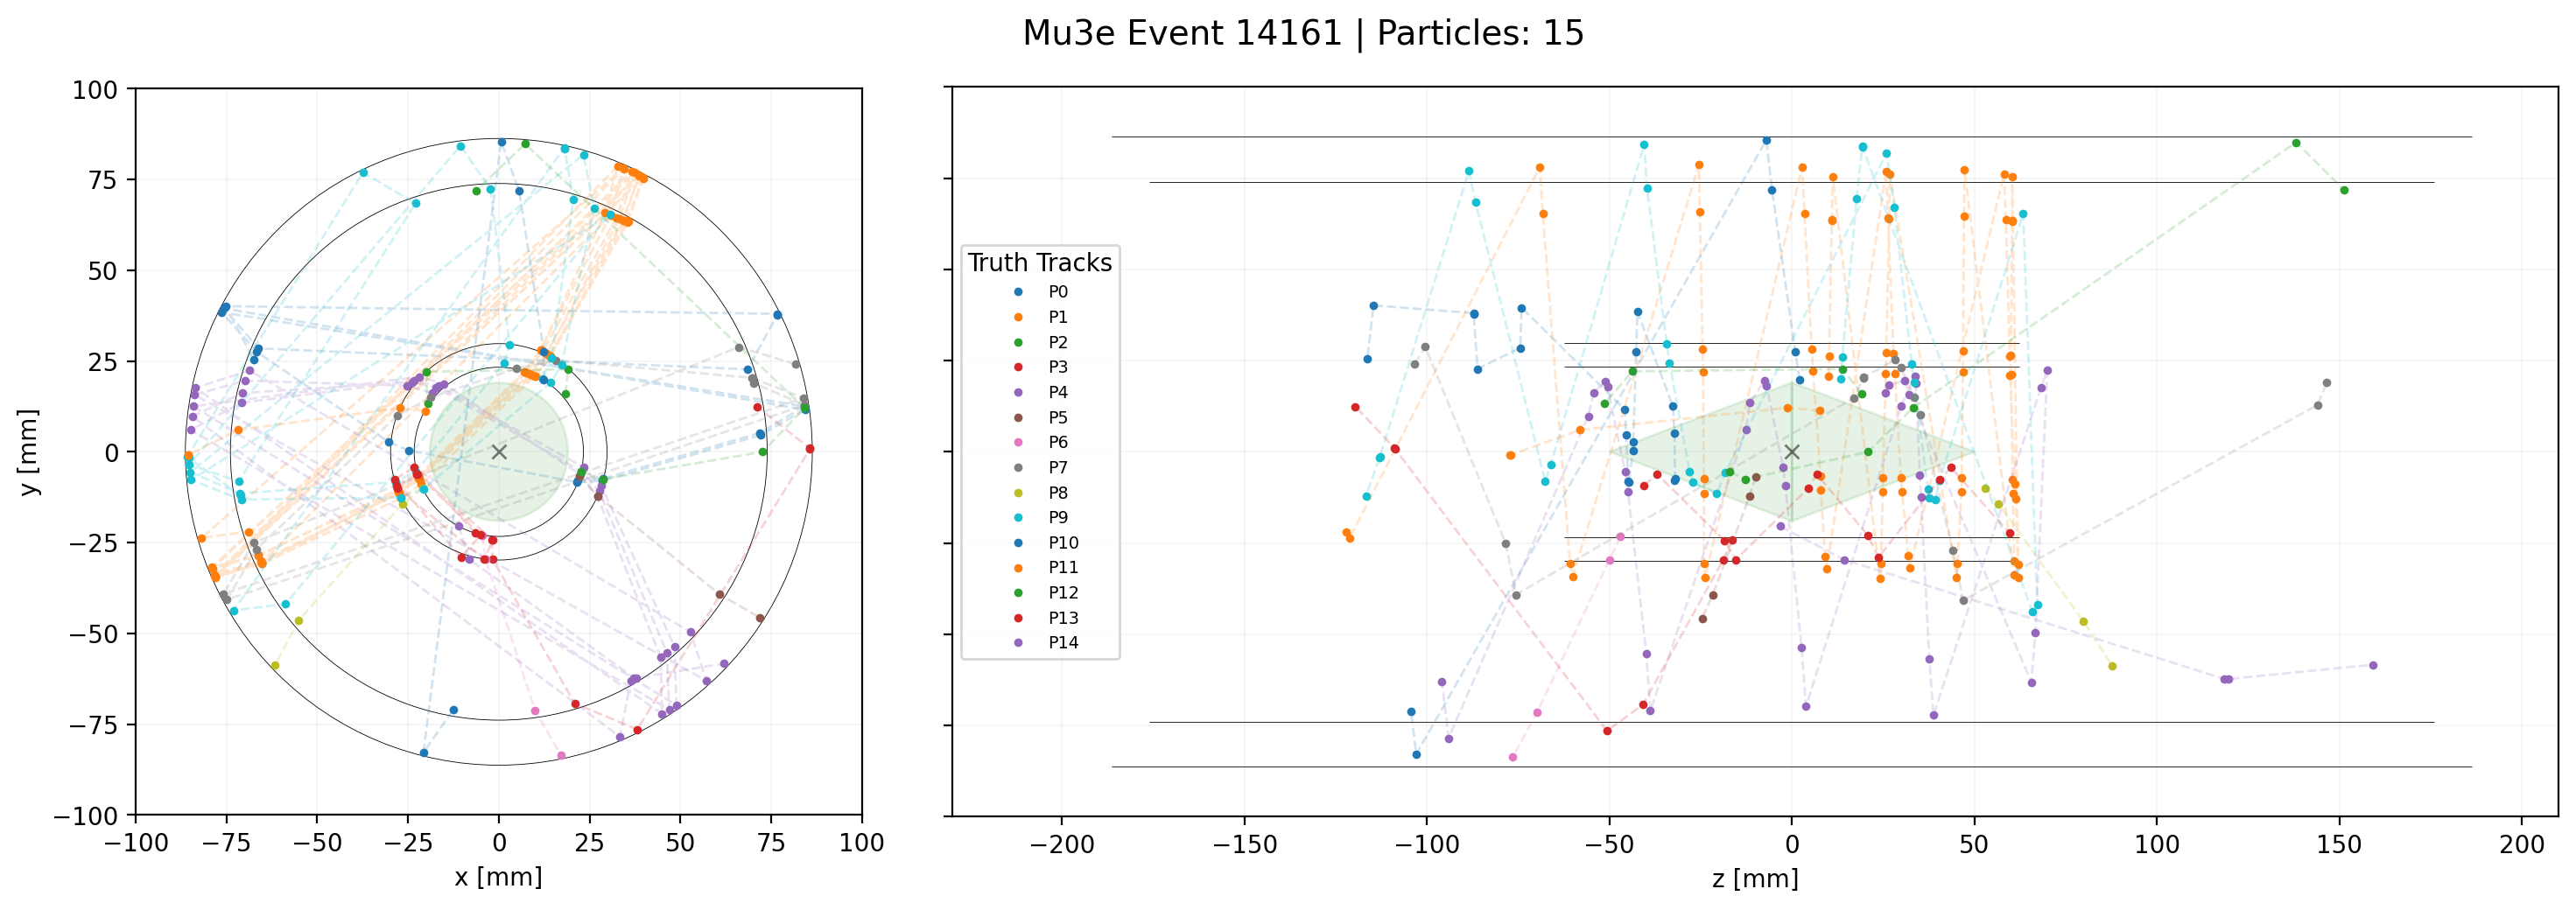

In [13]:
def plot_mu3e_dual_view(inputs, targets):
    b = 0  # since batch_size = 1
    plt.style.use('default')

    # extract event id
    event_id = int(targets['sample_id'][b].item()) # using sample_id from targets dict
    
    # setup figure
    fig, (ax1, ax2) = plt.subplots(
        1, 2, 
        figsize=(15, 5), 
        dpi=200, 
        sharey=True, 
        gridspec_kw={'width_ratios': [200, 460]}
    )
    
    # scale by 100 for mm scale
    h_x = inputs["hit_x"][b].detach().cpu().numpy() * 100
    h_y = inputs["hit_y"][b].detach().cpu().numpy() * 100
    h_z = inputs["hit_z"][b].detach().cpu().numpy() * 100
    valid_mask = inputs["hit_valid"][b].detach().cpu().numpy().astype(bool)

    # XY Plane
    ax1.set_xlim(-100, 100)
    ax1.set_ylim(-100, 100)
    ax1.set_aspect('equal')
    ax1.plot(0, 0, 'x', color='black', alpha=0.5)
    for r in [23.3, 29.8, 73.9, 86.3]:
        ax1.add_patch(Circle((0, 0), r, color='black', lw=0.3, fill=False))
    ax1.add_patch(Circle((0, 0), 19, color='green', alpha=0.1, label='Target'))

    # ZY Plane
    ax2.set_xlim(-230, 210)
    ax2.set_ylim(-100, 100)
    ax2.set_aspect('equal')
    ax2.plot(0, 0, 'x', color='black', alpha=0.5)
    # detector layer Z-bounds (Phase I)
    ax2.hlines(y=[+23.3, -23.3], xmin=-62.35,  xmax=62.35,  color='black', lw=0.3)
    ax2.hlines(y=[+29.8, -29.8], xmin=-62.35,  xmax=62.35,  color='black', lw=0.3)
    ax2.hlines(y=[+73.9, -73.9], xmin=-175.95, xmax=175.95, color='black', lw=0.3)
    ax2.hlines(y=[+86.3, -86.3], xmin=-186.3,  xmax=186.3,  color='black', lw=0.3)
    
    # Mu3e Stopping Target
    tgt1 = Polygon(np.array([[-50, 0], [0, 19], [0, -19]]), closed=True, color='green', alpha=0.1)
    tgt2 = Polygon(np.array([[50, 0], [0, 19], [0, -19]]), closed=True, color='green', alpha=0.1)
    ax2.add_patch(tgt1)
    ax2.add_patch(tgt2)

    # 6. Plot Tracks
    p_hit_val = targets["particle_hit_valid"][b].detach().cpu().numpy()
    p_valid = targets["particle_valid"][b].detach().cpu().numpy().astype(bool)
    num_particles = np.sum(p_valid)
    
    for p_idx in range(p_hit_val.shape[0]):
        if not p_valid[p_idx]: 
            continue
        
        # Mask hits belonging to this particle that are also valid
        this_p_mask = p_hit_val[p_idx].astype(bool) & valid_mask
        if not np.any(this_p_mask): 
            continue
        
        x_p, y_p, z_p = h_x[this_p_mask], h_y[this_p_mask], h_z[this_p_mask]
        
        ## Sort by Z to ensure track lines connect in order
        #sort_idx = np.argsort(z_p)
        #x_p, y_p, z_p = x_p[sort_idx], y_p[sort_idx], z_p[sort_idx]

        # Plot XY Projection
        line, = ax1.plot(x_p, y_p, '--', alpha=0.2, lw=1)
        color = line.get_color()
        ax1.plot(x_p, y_p, '.', color=color,markersize=5)

        # Plot ZY Projection
        ax2.plot(z_p, y_p, '--', alpha=0.2, lw=1, color=color)
        ax2.plot(z_p, y_p, '.', color=color, markersize=5, label=f'P{p_idx}')

    # 7. Labels & Polishing
    plt.suptitle(f'Mu3e Event {event_id} | Particles: {num_particles}', fontsize=14)
    ax1.set_xlabel('x [mm]')
    ax1.set_ylabel('y [mm]')
    ax2.set_xlabel('z [mm]')
    ax1.grid(alpha=0.1)
    ax2.grid(alpha=0.1)
    ax2.legend(loc='center left', fontsize='x-small', title="Truth Tracks")
    
    plt.tight_layout()
    return fig

fig = plot_mu3e_dual_view(inputs, targets)